In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D,
    Input, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


In [12]:
TRAIN_DIR = r"train"
TEST_DIR  = r"test"

IMG_SIZE    = (96, 96)
BATCH_SIZE  = 32
NUM_CLASSES = 7

EMOTION_LABELS = ['Angry', 'Disgusted', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']

In [14]:
train_data_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

validation_data_gen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_data_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',       # Load as RGB — MobileNetV2 requires 3 channels
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_data_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False           # Must be False for confusion matrix alignment
)

print("Class mapping:", train_generator.class_indices)
print(f"Train samples: {train_generator.samples}")
print(f"Val samples:   {validation_generator.samples}")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train samples: 28709
Val samples:   7178


In [15]:
def build_model(num_classes, img_size, freeze_base=True):
    """
    Builds MobileNetV2-based emotion classifier.
    freeze_base=True  → Phase 1 (train head only)
    freeze_base=False → Phase 2 (fine-tune top layers)
    """
    inputs = Input(shape=(*img_size, 3))

    # MobileNetV2 pretrained on ImageNet, without its original top classifier
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,       # Remove ImageNet classification head
        weights='imagenet'       # Use pretrained weights
    )
    base_model.trainable = not freeze_base

    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)   # Pool spatial features → single vector
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base_model


model, base_model = build_model(NUM_CLASSES, IMG_SIZE, freeze_base=True)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTrainable params (Phase 1): {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params (Phase 1): 361,735


In [16]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

STEPS_TRAIN = train_generator.samples // BATCH_SIZE
STEPS_VAL   = validation_generator.samples // BATCH_SIZE

print("=== Phase 1: Training classifier head (base frozen) ===")
history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=STEPS_TRAIN,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=STEPS_VAL,
    callbacks=callbacks_phase1
)

=== Phase 1: Training classifier head (base frozen) ===
Epoch 1/20


c:\Users\ganga\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.3010 - loss: 1.7815
Epoch 1: val_accuracy improved from -inf to 0.41908, saving model to best_phase1.keras
897/897 ━━━━━━━━━━━━━━━━━━━━ 605s 667ms/step - accuracy: 0.3010 - loss: 1.7814 - val_accuracy: 0.4191 - val_loss: 1.5253 - learning_rate: 0.0010
Epoch 2/20
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:19 89ms/step - accuracy: 0.5000 - loss: 1.3373
Epoch 2: val_accuracy improved from 0.41908 to 0.50000, saving model to best_phase1.keras


c:\Users\ganga\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


897/897 ━━━━━━━━━━━━━━━━━━━━ 1s 466us/step - accuracy: 0.5000 - loss: 1.3373 - val_accuracy: 0.5000 - val_loss: 1.4774 - learning_rate: 0.0010
Epoch 3/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3855 - loss: 1.5803
Epoch 3: val_accuracy did not improve from 0.50000
897/897 ━━━━━━━━━━━━━━━━━━━━ 112s 125ms/step - accuracy: 0.3856 - loss: 1.5803 - val_accuracy: 0.4224 - val_loss: 1.5128 - learning_rate: 0.0010
Epoch 4/20
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:17 86ms/step - accuracy: 0.5000 - loss: 1.3989
Epoch 4: val_accuracy did not improve from 0.50000
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 67us/step - accuracy: 0.5000 - loss: 1.3989 - val_accuracy: 0.5000 - val_loss: 1.6406 - learning_rate: 0.0010
Epoch 5/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4084 - loss: 1.5330
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.50000
897/897 ━━━━━━━━━━━━━━━━━━━━ 128s 143ms/step - accuracy: 0.4084 - loss: 1.5

In [17]:
# Unfreeze top 30 layers of the base model for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params (Phase 2): {trainable_count:,}")

# Much lower learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_phase2.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\n=== Phase 2: Fine-tuning top layers of MobileNetV2 ===")
history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=STEPS_TRAIN,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=STEPS_VAL,
    callbacks=callbacks_phase2
)

Trainable params (Phase 2): 1,888,135

=== Phase 2: Fine-tuning top layers of MobileNetV2 ===
Epoch 1/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.3305 - loss: 1.7404
Epoch 1: val_accuracy improved from -inf to 0.43973, saving model to best_phase2.keras
897/897 ━━━━━━━━━━━━━━━━━━━━ 164s 172ms/step - accuracy: 0.3305 - loss: 1.7403 - val_accuracy: 0.4397 - val_loss: 1.4876 - learning_rate: 1.0000e-05
Epoch 2/30
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:36 107ms/step - accuracy: 0.3125 - loss: 1.6455
Epoch 2: val_accuracy improved from 0.43973 to 0.50000, saving model to best_phase2.keras
897/897 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step - accuracy: 0.3125 - loss: 1.6455 - val_accuracy: 0.5000 - val_loss: 1.7770 - learning_rate: 1.0000e-05
Epoch 3/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4165 - loss: 1.5240
Epoch 3: val_accuracy did not improve from 0.50000
897/897 ━━━━━━━━━━━━━━━━━━━━ 146s 162ms/step - accuracy: 0.4165 - loss: 1.5239 - val_accuracy: 0.4509 - val_loss: 1.

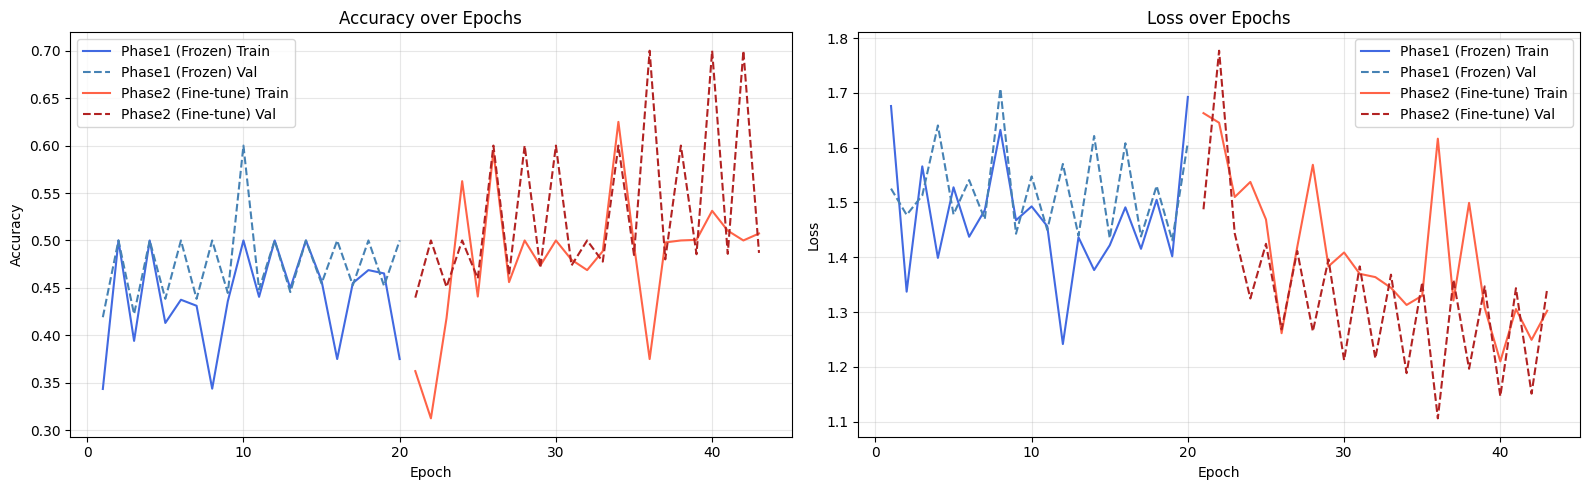


Best Validation Accuracy across both phases: 0.7000 (70.00%)


In [18]:
def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    colors = [('royalblue', 'steelblue'), ('tomato', 'firebrick')]

    offset = 0
    for i, (hist, label) in enumerate(zip(histories, labels)):
        epochs = range(offset + 1, offset + len(hist.history['accuracy']) + 1)

        axes[0].plot(epochs, hist.history['accuracy'],     color=colors[i][0], label=f'{label} Train')
        axes[0].plot(epochs, hist.history['val_accuracy'], color=colors[i][1], label=f'{label} Val', linestyle='--')

        axes[1].plot(epochs, hist.history['loss'],         color=colors[i][0], label=f'{label} Train')
        axes[1].plot(epochs, hist.history['val_loss'],     color=colors[i][1], label=f'{label} Val', linestyle='--')

        offset += len(hist.history['accuracy'])

    for ax, title, ylabel in zip(axes,
                                  ['Accuracy over Epochs', 'Loss over Epochs'],
                                  ['Accuracy', 'Loss']):
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()


plot_history(
    [history_phase1, history_phase2],
    ['Phase1 (Frozen)', 'Phase2 (Fine-tune)']
)

best_val_acc = max(
    max(history_phase1.history['val_accuracy']),
    max(history_phase2.history['val_accuracy'])
)
print(f"\nBest Validation Accuracy across both phases: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step


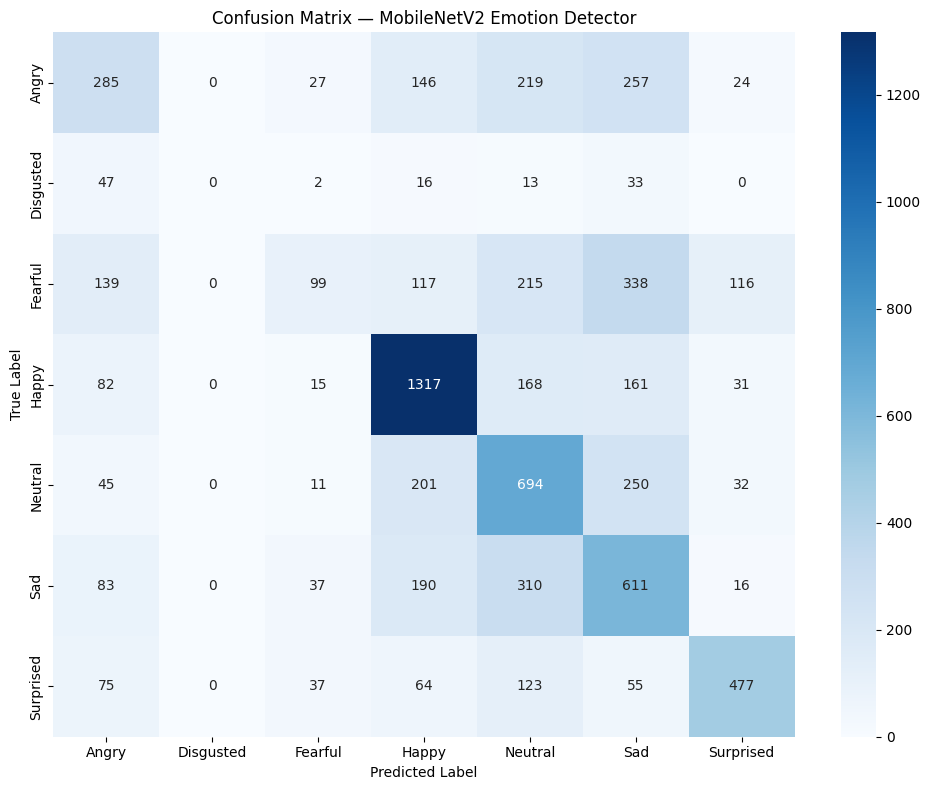


Classification Report:
              precision    recall  f1-score   support

       Angry       0.38      0.30      0.33       958
   Disgusted       0.00      0.00      0.00       111
     Fearful       0.43      0.10      0.16      1024
       Happy       0.64      0.74      0.69      1774
     Neutral       0.40      0.56      0.47      1233
         Sad       0.36      0.49      0.41      1247
   Surprised       0.69      0.57      0.62       831

    accuracy                           0.49      7178
   macro avg       0.41      0.39      0.38      7178
weighted avg       0.48      0.49      0.46      7178



c:\Users\ganga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ganga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ganga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [19]:
validation_generator.reset()

y_pred_probs = model.predict(
    validation_generator,
    steps=STEPS_VAL + 1,
    verbose=1
)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes[:len(y_pred)]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=EMOTION_LABELS,
    yticklabels=EMOTION_LABELS
)
plt.title('Confusion Matrix — MobileNetV2 Emotion Detector')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))

In [20]:
model.save('emotion_mobilenetv2_final.keras')

# Also save in legacy format for inference notebook compatibility
model_json = model.to_json()
with open('emotion_model.json', 'w') as f:
    f.write(model_json)
model.save_weights('emotion_model_weights.weights.h5')

print("Model saved: emotion_mobilenetv2_final.keras")
print("Also saved: emotion_model.json + emotion_model_weights.weights.h5")

Model saved: emotion_mobilenetv2_final.keras
Also saved: emotion_model.json + emotion_model_weights.weights.h5
